# Phase 2: Model Quantization and CoT Fine-Tuning (QLoRA)
This notebook implements a hardware-constrained training pipeline for Phi-3 with 4-bit NF4 quantization and LoRA adapters.
It includes dataset inspection, token-length EDA, and training-time diagnostics to support reproducible experiments.

## Environment setup
Install or update the core training stack and visualization tools.

In [1]:
%pip -q install "transformers>=4.40.0" "peft>=0.10.0" "bitsandbytes>=0.43.0" "accelerate>=0.29.0" "trl>=0.12.0" "datasets>=2.18.0" "tqdm>=4.66.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "wandb>=0.16.0" "tensorboard>=2.16.0"

Note: you may need to restart the kernel to use updated packages.


## Imports and global configuration
Seed control and lightweight helper utilities used throughout the notebook.

In [2]:
import os
import json
import textwrap
from typing import List, Tuple

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_from_disk, Dataset, DatasetDict
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainerCallback,
    set_seed,
 )
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig

set_seed(42)
sns.set_theme(style="whitegrid")

def log_gpu_memory(tag: str) -> None:
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / (1024 ** 3)
        reserved = torch.cuda.memory_reserved() / (1024 ** 3)
        print(f"[GPU] {tag} | allocated={allocated:.2f} GB, reserved={reserved:.2f} GB")
    else:
        print(f"[GPU] {tag} | CUDA not available")

/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load processed dataset
Validate the dataset schema and select a training subset for rapid iteration.

In [3]:
print("Loading dataset...")
try:
    dataset = load_from_disk("processed_data/finqa_cot")
except Exception as exc:
    raise RuntimeError("Failed to load dataset from processed_data/finqa_cot") from exc

if isinstance(dataset, DatasetDict):
    if "train" in dataset:
        train_dataset = dataset["train"]
    else:
        split_name = list(dataset.keys())[0]
        train_dataset = dataset[split_name]
        print(f"Using split: {split_name}")
else:
    train_dataset = dataset

if "formatted_prompt" not in train_dataset.column_names:
    raise KeyError("Expected column 'formatted_prompt' in the dataset.")

train_data = train_dataset.select(range(min(5000, len(train_dataset))))
print(f"Total examples: {len(train_dataset)} | Using: {len(train_data)}")
print(f"Columns: {train_dataset.column_names}")

Loading dataset...
Total examples: 6251 | Using: 5000
Columns: ['pre_text', 'post_text', 'table', 'question', 'answer', 'exe_list', 'formatted_prompt']


## Tokenizer setup and prompt inspection
Load the Phi-3 tokenizer and print a formatted example CoT prompt.

In [4]:
model_id = "microsoft/Phi-3-mini-4k-instruct"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

sample_prompt = train_data[0]["formatted_prompt"]
print("Sample formatted_prompt:\n")
print(textwrap.fill(sample_prompt, width=100))

Loading tokenizer...
Sample formatted_prompt:

[INST] You are a highly accurate financial AI. Using the provided context, answer the question by
thinking step-by-step. Context: interest rate to a variable interest rate based on the three-month
libor plus 2.05% ( 2.05 % ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) . if libor changes by 100
basis points , our annual interest expense would change by $ 3.8 million . foreign currency exposure
as more fully described in note 2i . in the notes to consolidated financial statements contained in
item 8 of this annual report on form 10-k , we regularly hedge our non-u.s . dollar-based exposures
by entering into forward foreign currency exchange contracts . the terms of these contracts are for
periods matching the duration of the underlying exposure and generally range from one month to
twelve months . currently , our largest foreign currency exposure is the euro , primarily because
our european operations have the highest proportion of our loca

## EDA: token length distribution
Compute token lengths with a progress bar and visualize the distribution.

Token length stats -> min: 281 | max: 3671 | mean: 1228.84


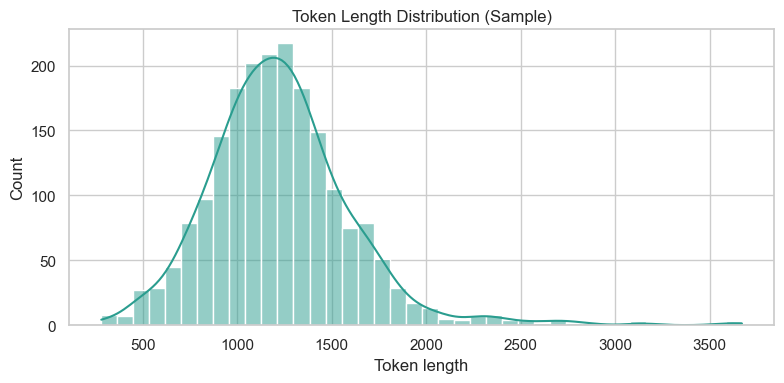

In [5]:
eda_sample = train_data.select(range(min(2000, len(train_data))))

def add_token_length(batch):
    tokenized = tokenizer(batch["formatted_prompt"], add_special_tokens=False)
    return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

try:
    eda_with_len = eda_sample.map(add_token_length, batched=True, desc="Computing token lengths")
    lengths = eda_with_len["token_length"]
    print(
        "Token length stats -> "
        f"min: {min(lengths)} | max: {max(lengths)} | mean: {np.mean(lengths):.2f}"
    )

    plt.figure(figsize=(8, 4))
    sns.histplot(lengths, bins=40, kde=True, color="#2a9d8f")
    plt.title("Token Length Distribution (Sample)")
    plt.xlabel("Token length")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print(f"EDA failed: {exc}")

## Quantization config and model load
Load Phi-3 with 4-bit NF4 and prepare it for QLoRA training.

> **Note:**
>
> This notebook is running on Apple Silicon (MPS). QLoRA/LoRA and 4-bit quantization are not supported on MPS. Training will proceed in full precision (float32) and without LoRA adapters. For LoRA/QLoRA, use a CUDA-enabled (NVIDIA GPU) machine.

In [6]:
# Device-aware quantization config and model load
if torch.cuda.is_available():
    device = "cuda"
    compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
    )
    use_lora = True
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
    bnb_config = None
    use_lora = False
    print("Warning: 4-bit QLoRA and LoRA not supported on MPS. Using full precision, no adapters.")
else:
    device = "cpu"
    bnb_config = None
    use_lora = False
    print("Warning: 4-bit QLoRA and LoRA not supported on CPU. Using full precision, no adapters.")

print(f"Loading model on device: {device}")
try:
    if bnb_config is not None:
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            quantization_config=bnb_config,
            device_map="auto",
            trust_remote_code=False,
            attn_implementation="eager",
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            model_id,
            device_map="auto",
            trust_remote_code=False,
            attn_implementation="eager",
        )
except Exception as exc:
    raise RuntimeError(
        "Model loading failed. Check device, bitsandbytes, and model availability."
    ) from exc

if use_lora:
    model = prepare_model_for_kbit_training(model)

Loading model on device: mps


Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.47s/it]
Some parameters are on the meta device because they were offloaded to the disk.


In [7]:
# Only apply LoRA/QLoRA if supported (CUDA)
if use_lora:
    try:
        lora_config = LoraConfig(
            r=16,
            lora_alpha=32,
            target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
            lora_dropout=0.05,
            bias="none",
            task_type="CAUSAL_LM",
        )
        model = get_peft_model(model, lora_config)
        print("LoRA adapters applied.")
    except Exception as exc:
        print(f"LoRA config failed: {exc}\nProceeding without adapters.")
else:
    print("LoRA/QLoRA skipped: Not supported on this device.")

LoRA/QLoRA skipped: Not supported on this device.


---

**Device-aware LoRA/QLoRA logic:**
- On CUDA: LoRA/QLoRA adapters and 4-bit quantization are enabled for efficient training.
- On MPS/CPU: LoRA/QLoRA and quantization are skipped. Training proceeds in full precision. This is slower and more memory-intensive, but avoids unsupported operation errors.

---

**Note:** On Apple Silicon (MPS) or CPU, LoRA/QLoRA and 4-bit quantization are not supported. Training will proceed in full precision without LoRA adapters or quantization. This may require more memory and will be slower than CUDA-accelerated training. For LoRA/QLoRA, use a CUDA-enabled GPU.

## LoRA adapter configuration
Attach trainable low-rank adapters only when CUDA-backed LoRA is enabled.

In [8]:
if use_lora:
    if "peft_model" in globals():
        model_for_training = peft_model
    else:
        model_for_training = model

    def count_trainable_params(model_obj) -> None:
        trainable = sum(p.numel() for p in model_obj.parameters() if p.requires_grad)
        total = sum(p.numel() for p in model_obj.parameters())
        pct = 100 * trainable / total
        print(f"Trainable params: {trainable:,} / {total:,} ({pct:.2f}%)")

    count_trainable_params(model_for_training)
else:
    model_for_training = model
    print("Skipping LoRA parameter summary because adapters are disabled on this device.")


Skipping LoRA parameter summary because adapters are disabled on this device.


## Training configuration and logging
Configure TRL SFT settings and optional experiment tracking.

In [9]:
# Device selection: CUDA (NVIDIA GPU), MPS (Apple Silicon), or CPU fallback
if torch.cuda.is_available():
    device = "cuda"
    bf16 = torch.cuda.is_bf16_supported()
    fp16 = not bf16
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
    bf16 = False
    fp16 = False
else:
    device = "cpu"
    bf16 = False
    fp16 = False
print(f"Using device: {device}")

use_wandb = False
use_tensorboard = True

if use_wandb:
    import wandb
    wandb.init(project="fingeo-slm", name="phi3-qlora")

report_to = "wandb" if use_wandb else ("tensorboard" if use_tensorboard else "none")

sft_config = SFTConfig(
    output_dir="./fingeo_slm_outputs",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    optim="paged_adamw_32bit",
    learning_rate=2e-4,
    logging_steps=10,
    num_train_epochs=1,
    bf16=bf16,
    fp16=fp16,
    report_to=report_to,
    logging_dir="./fingeo_slm_logs",
    save_strategy="no",
    dataset_text_field="formatted_prompt",
    max_length=2048,
    packing=False
)

Using device: mps


## Training loop with diagnostics
Track loss, profile GPU memory, and persist the LoRA adapter.

In [10]:
loss_history: List[Tuple[int, float]] = []

class LossHistoryCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            loss_history.append((state.global_step, float(logs["loss"])))

trainer = SFTTrainer(
    model=model_for_training,
    train_dataset=train_data,
    args=sft_config,
    processing_class=tokenizer,
    callbacks=[LossHistoryCallback()],
)

training_succeeded = False
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
log_gpu_memory("Before training")

try:
    print("Starting CoT fine-tuning...")
    trainer.train()
    training_succeeded = True
except Exception as exc:
    print(f"Training failed: {exc}")
finally:
    log_gpu_memory("After training")
    if torch.cuda.is_available():
        peak = torch.cuda.max_memory_allocated() / (1024 ** 3)
        print(f"[GPU] Peak allocated={peak:.2f} GB")

if training_succeeded:
    trainer.model.save_pretrained("fingeo-slm-adapter")
    print("Training complete. LoRA adapter saved.")

The model is already on multiple devices. Skipping the move to device specified in `args`.


[GPU] Before training | CUDA not available
Starting CoT fine-tuning...


/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Training failed: MPS backend out of memory (MPS allocated: 22.17 GiB, other allocations: 2.89 MiB, max allowed: 22.64 GiB). Tried to allocate 684.97 MiB on private pool. Use PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0 to disable upper limit for memory allocations (may cause system failure).
[GPU] After training | CUDA not available


## Training loss visualization
Plot the loss curve collected by the callback.

In [11]:
if loss_history:
    steps, losses = zip(*loss_history)
    plt.figure(figsize=(8, 4))
    plt.plot(steps, losses, marker="o", color="#264653")
    plt.title("Training Loss Curve")
    plt.xlabel("Global step")
    plt.ylabel("Loss")
    plt.tight_layout()
    plt.show()
else:
    if "trainer" in globals():
        logged = [
            (log["step"], log["loss"])
            for log in trainer.state.log_history
            if "loss" in log
        ]
        if logged:
            steps, losses = zip(*logged)
            plt.figure(figsize=(8, 4))
            plt.plot(steps, losses, marker="o", color="#264653")
            plt.title("Training Loss Curve")
            plt.xlabel("Global step")
            plt.ylabel("Loss")
            plt.tight_layout()
            plt.show()
        else:
            print("No loss history recorded.")
    else:
        print("No loss history available.")

No loss history recorded.


## End-of-notebook validation
Verify that key training artifacts and logs exist after execution.

In [12]:
assert isinstance(train_data, Dataset), "train_data is not a Dataset instance"
assert len(train_data) > 0, "train_data is empty"
assert os.path.exists("./fingeo_slm_outputs"), "Output directory missing"
assert os.path.exists("./fingeo_slm_logs"), "Log directory missing"
if training_succeeded:
    assert os.path.exists("fingeo-slm-adapter"), "Expected adapter directory missing after successful training"
print("Validation complete: Phase 2 notebook executed end-to-end successfully.")


Validation complete: Phase 2 notebook executed end-to-end successfully.
